# Password Strength Classification 
## Objective

The goal of this project is to classify passwords into three categories:
- Weak
- Medium
- Strong

using NLP techniques and Machine Learning models.

## Import Libraries

In [81]:
import pandas as pd
import matplotlib.pyplot as plt

## Load the dataset

In [82]:
df=pd.read_csv("../data/passwords_dataset.csv")

## Data Understanding

In [83]:
df.head()

,password,strength
0,0TWGA*8lTv#6,2
1,"39NW0y.y6r""",2
2,;QbEP2Df,2
3,pIr9*wdHF.A,2
4,tl.*<X32,2


In [84]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 42851 entries, 0 to 42850
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   password  42850 non-null  object
 1   strength  42851 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 669.7+ KB


In [85]:
df.isnull().sum()

password    1
strength    0
dtype: int64

In [86]:
df.dropna(inplace=True)

In [87]:
df.describe()

,strength
count,42850.000000
mean,0.741820
std,0.691087
min,0.000000
25%,0.000000
50%,1.000000
75%,1.000000
max,2.000000


##  Exploratory Data Analysis (EDA)

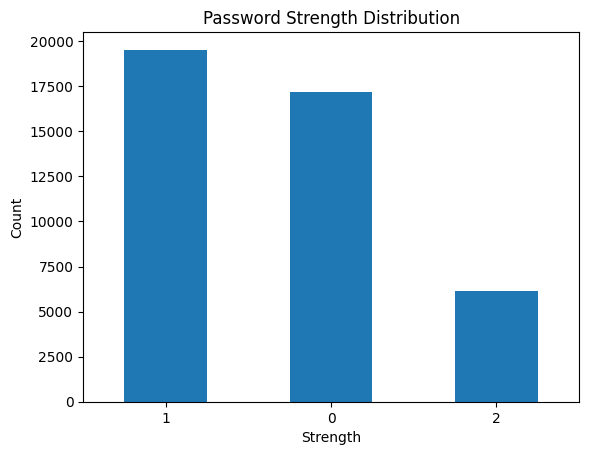

In [88]:
df["strength"].value_counts().plot(kind="bar",rot=0)
plt.title("Password Strength Distribution")
plt.xlabel("Strength")
plt.ylabel("Count")
plt.show()


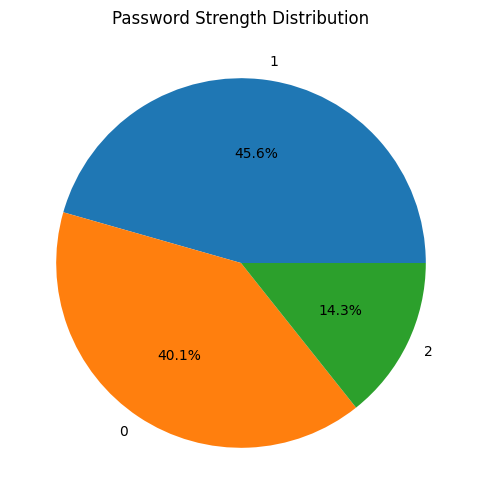

In [89]:
df["strength"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%",
    figsize=(6,6)
)

plt.title("Password Strength Distribution")
plt.ylabel("")
plt.show()

## Data Splitting

In [90]:
X=df.drop("strength",axis=1)
y=df["strength"]

In [91]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,stratify=y,random_state=42)

## Data Preprocessing

In [92]:
from sklearn.feature_extraction.text import TfidfVectorizer
vectorizer=TfidfVectorizer(analyzer="char",ngram_range=(1,2))
X_train_vec=vectorizer.fit_transform(X_train["password"])
X_test_vec=vectorizer.transform(X_test["password"])

## Model Training

### 1-Logistic Regression

In [93]:
from sklearn.linear_model import LogisticRegression
lg=LogisticRegression(class_weight="balanced",max_iter=1000)
lg.fit(X_train_vec,y_train)

LogisticRegression(class_weight='balanced', max_iter=1000)

In [94]:
pred_lg=lg.predict(X_test_vec)

### 2-Linear SVM

In [95]:
from sklearn.svm import LinearSVC
svm=LinearSVC(class_weight="balanced")
svm.fit(X_train_vec, y_train)


LinearSVC(class_weight='balanced')

In [96]:
pred_svm=svm.predict(X_test_vec)

## Model Evaluation

In [97]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report

acc_df = pd.DataFrame({
    "Model": ["Logistic Regression","Linear SVM"],
    "Accuracy": [
        accuracy_score(y_test, pred_lg),
        accuracy_score(y_test,pred_svm)
    ]
})

acc_df

,Model,Accuracy
0,Logistic Regression,0.873046
1,Linear SVM,0.874796


In [98]:
from sklearn.metrics import classification_report

print("Logistic Regression")
print(classification_report(y_test, pred_lg))

print("Linear SVM")
print(classification_report(y_test, pred_svm))

Logistic Regression
              precision    recall  f1-score   support

           0       0.87      0.89      0.88      3438
           1       0.89      0.83      0.86      3906
           2       0.85      0.95      0.90      1226

    accuracy                           0.87      8570
   macro avg       0.87      0.89      0.88      8570
weighted avg       0.87      0.87      0.87      8570

Linear SVM
              precision    recall  f1-score   support

           0       0.89      0.89      0.89      3438
           1       0.87      0.86      0.86      3906
           2       0.85      0.90      0.87      1226

    accuracy                           0.87      8570
   macro avg       0.87      0.88      0.88      8570
weighted avg       0.87      0.87      0.87      8570



## Save the model

In [99]:
import pickle
with open("../models/model.pkl", "wb") as f:
    pickle.dump(svm,f)

with open("../models/tfidf_vectorizer.pkl", "wb") as v:
    pickle.dump(vectorizer,v)

## Conclusion

In this project, different Machine Learning approaches were explored to classify passwords based on their strength.

After evaluating Logistic Regression and Linear SVM, Linear SVM achieved the best overall performance and was selected as the final model.

The trained model and TF-IDF vectorizer were saved for future deployment in a Streamlit application.